# Hypothesis tests, power and the ways they go wrong — toy examples

Every test is simulated first so the p-value is something you *computed*, then reproduced
with `scipy.stats`. The second half is about the traps: dependence, multiple comparisons,
optional stopping, and confusing significance with size.

**What's in here**
- what a null hypothesis is; the p-value as a tail probability by simulation
- permutation test from scratch; why it is wrong on hourly data and right on daily blocks
- type I / type II errors, power curves, minimum detectable effect, "how many days do I need?"
- one- vs two-sided; paired vs unpaired; non-parametric alternatives
- multiple comparisons: Bonferroni, Benjamini-Hochberg, the "best of 20 variants" trap
- optional stopping / p-hacking by simulation
- significance vs effect size at large n
- t-stats for regression coefficients under autocorrelated residuals (Newey-West by hand)
- normality tests at large n; a Bayesian one-liner
- what to say in the interview

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
df["dow"] = df["time"].dt.dayofweek
df["weekend"] = df["dow"] >= 5

## 1. The logic of a null hypothesis

H0: "the two groups come from the same distribution". Simulate that world many times, record
the test statistic each time, and the p-value of your observed statistic is the fraction of
H0-worlds that produced something at least as extreme.

**Interview check:** a p-value is P(data this extreme | H0). It is *not* P(H0 | data), and
1−p is not the probability your effect is real.

In [2]:
n1 = n2 = 40
obs_a = rng.normal(100, 15, n1); obs_b = rng.normal(108, 15, n2)     # true difference 8
t_obs = (obs_a.mean() - obs_b.mean()) / np.sqrt(obs_a.var(ddof=1)/n1 + obs_b.var(ddof=1)/n2)

# the H0 world: both groups drawn from the SAME distribution
sim_a = rng.normal(100, 15, size=(20_000, n1)); sim_b = rng.normal(100, 15, size=(20_000, n2))
t_sim = (sim_a.mean(1) - sim_b.mean(1)) / np.sqrt(sim_a.var(1, ddof=1)/n1 + sim_b.var(1, ddof=1)/n2)

p_sim = (np.abs(t_sim) >= abs(t_obs)).mean()
t_sp, p_sp = stats.ttest_ind(obs_a, obs_b, equal_var=False)
print(f"observed t = {t_obs:.2f}   p by simulation = {p_sim:.4f}   scipy Welch t-test p = {p_sp:.4f}")

observed t = -2.92   p by simulation = 0.0048   scipy Welch t-test p = 0.0046


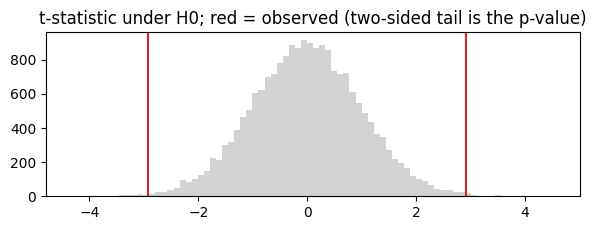

In [3]:
fig, ax = plt.subplots(figsize=(6, 2.4))
ax.hist(t_sim, bins=80, color="lightgrey"); ax.axvline(t_obs, color="tab:red"); ax.axvline(-t_obs, color="tab:red")
ax.set_title("t-statistic under H0; red = observed (two-sided tail is the p-value)"); plt.tight_layout()

## 2. Permutation test from scratch

If H0 is true the group labels are exchangeable: shuffle them, recompute the statistic, repeat.
No distributional assumption. Test "weekend consumption differs from weekday" on the real
data.

**Pitfall:** exchangeability is the assumption. Hourly observations are not exchangeable
(the hour after a weekend hour is almost certainly another weekend hour), so permuting
17,520 hourly labels gives a wildly overconfident p-value. Permute *days* instead.

In [4]:
def perm_test(values, labels, n_perm=2000):
    obs = values[labels].mean() - values[~labels].mean()
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        l = rng.permutation(labels)
        diffs[i] = values[l].mean() - values[~l].mean()
    return obs, (np.abs(diffs) >= abs(obs)).mean(), diffs.std()

# (a) hourly rows: p is "zero" and the null spread is tiny
obs_h, p_h, sd_h = perm_test(df["consumption_mwh"].to_numpy(), df["weekend"].to_numpy(), 500)
# (b) daily means: the honest unit of observation
daily = df.groupby(df["time"].dt.date).agg(cons=("consumption_mwh", "mean"), weekend=("weekend", "first"))
obs_d, p_d, sd_d = perm_test(daily["cons"].to_numpy(), daily["weekend"].to_numpy(), 2000)
pd.DataFrame({"unit": ["hour", "day"], "n": [len(df), len(daily)], "observed diff (MWh)": [obs_h, obs_d],
              "null SD of diff": [sd_h, sd_d], "p (perm)": [p_h, p_d]}).round(3)

,unit,n,observed diff (MWh),null SD of diff,p (perm)
0,hour,17520,-2082.475,73.659,0.0
1,day,730,-2082.475,182.008,0.0


Here the weekend effect is large (about −2,200 MWh by construction), so both p-values are
tiny. The lesson is in the **null SD** column: the hourly version thinks the effect is
measured about 2.5× more precisely than it really is (and the true daily unit is itself
optimistic, since consecutive days are correlated). For a small effect that difference decides the
verdict.

## 3. Type I, type II, power

- Type I error: reject H0 when it is true. Rate = α by construction (check it!).
- Type II error: fail to reject when the effect is real. Power = 1 − β.
- Power rises with n and with effect size; α, n, effect and power are linked, fix three and
  the fourth follows.

In [5]:
def reject_rate(effect, n, alpha=0.05, sims=4000, sd=1.0):
    a = rng.normal(0, sd, size=(sims, n)); b = rng.normal(effect, sd, size=(sims, n))
    p = stats.ttest_ind(a, b, axis=1).pvalue
    return (p < alpha).mean()

effects = [0.0, 0.2, 0.5, 0.8]
table = pd.DataFrame({f"d={d}": [reject_rate(d, n) for n in [20, 50, 200]] for d in effects}, index=[20, 50, 200])
table.index.name = "n per group"
table.round(3)          # first column is the type I rate (≈0.05); the rest are power

,d=0.0,d=0.2,d=0.5,d=0.8
n per group,,,,
20,0.046,0.092,0.332,0.691
50,0.042,0.173,0.688,0.979
200,0.048,0.509,0.999,1.000


### Minimum detectable effect and "how many days do I need?"

A/B test of two forecast models: paired daily RMSE, model B is 2% better on average, day-to-day
noise in the paired difference is 8% of RMSE. How many days to have 80% power at α = 0.05?
Analytical: n ≈ ((z_{1−α/2} + z_{power}) · σ_d / δ)². Then confirm by simulation.

In [6]:
delta, sd_d = 0.02, 0.08
z = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
n_formula = (z * sd_d / delta) ** 2
print(f"n by formula ≈ {n_formula:.0f} days")

rows = []
for n in [30, 60, 90, 130, 200]:
    d = rng.normal(delta, sd_d, size=(4000, n))
    rows.append({"days": n, "power (paired t)": (stats.ttest_1samp(d, 0, axis=1).pvalue < 0.05).mean()})
pd.DataFrame(rows).round(3)

n by formula ≈ 126 days


,days,power (paired t)
0,30,0.275
1,60,0.475
2,90,0.660
3,130,0.809
4,200,0.944


**Interview check:** "we ran the new model for two weeks and it was 2% better, is it
significant?" With that noise level, two weeks has power ≈ 15%: even if the improvement is
real you will usually fail to detect it, and if you *did* get p < 0.05 the estimated effect
is probably inflated (the winner's curse).

## 4. One- vs two-sided, paired vs unpaired, non-parametric

- Two-sided unless you decided the direction *before* looking (rare in practice).
- Paired when the same units are measured twice (two models on the same days): the pairing
  removes the day-to-day variance, so the test is far more powerful.
- Mann-Whitney / Wilcoxon compare ranks: robust to outliers and skew, less powerful under
  normality, and they test a different hypothesis (stochastic dominance, not the mean).

In [7]:
n = 60
day_effect = rng.normal(0, 1.0, n)                   # shared day-to-day difficulty
err_a = 1.0 + day_effect + rng.normal(0, 0.2, n)     # model A daily RMSE
err_b = 0.85 + day_effect + rng.normal(0, 0.2, n)    # model B: 0.15 better
rows = {
    "unpaired Welch t": stats.ttest_ind(err_a, err_b, equal_var=False).pvalue,
    "paired t (ttest_rel)": stats.ttest_rel(err_a, err_b).pvalue,
    "one-sided paired (A > B)": stats.ttest_rel(err_a, err_b, alternative="greater").pvalue,
    "Mann-Whitney (unpaired ranks)": stats.mannwhitneyu(err_a, err_b).pvalue,
    "Wilcoxon signed-rank (paired ranks)": stats.wilcoxon(err_a, err_b).pvalue,
}
pd.Series(rows, name="p-value").round(4)

unpaired Welch t                       0.5492
paired t (ttest_rel)                   0.0047
one-sided paired (A > B)               0.0023
Mann-Whitney (unpaired ranks)          0.5237
Wilcoxon signed-rank (paired ranks)    0.0090
Name: p-value, dtype: float64

The Diebold-Mariano test for comparing forecasts is exactly this paired idea applied to the
loss differential d_t = e²_{A,t} − e²_{B,t}, with the SE of mean(d) corrected for
autocorrelation (see notebook 03, section 6).

## 5. Multiple comparisons

Test 50 pure-noise features against a noise target at α = 0.05: about 2.5 will be
"significant". Bonferroni controls the family-wise error (divide α by m); Benjamini-Hochberg
controls the false discovery rate (less conservative, usually the right tool for screening).

In [8]:
n, m = 500, 50
X = rng.normal(size=(n, m)); y = rng.normal(size=n)
p = np.array([stats.pearsonr(X[:, j], y).pvalue for j in range(m)])

bonf = p < 0.05 / m
# Benjamini-Hochberg by hand
order = np.argsort(p); ranked = p[order]; thresh = 0.05 * np.arange(1, m + 1) / m
k = np.max(np.where(ranked <= thresh)[0]) + 1 if np.any(ranked <= thresh) else 0
bh = np.zeros(m, bool); bh[order[:k]] = True
bh_scipy = stats.false_discovery_control(p) < 0.05

print(f"raw p<0.05: {(p < 0.05).sum()} of {m} noise features   Bonferroni: {bonf.sum()}   BH by hand: {bh.sum()}   BH scipy: {bh_scipy.sum()}")

raw p<0.05: 3 of 50 noise features   Bonferroni: 0   BH by hand: 0   BH scipy: 0


### The "best of 20 variants" trap

You try 20 model variants, all equally good in truth, and report the best one's improvement
over the baseline with its own p-value. The max of 20 noisy estimates is biased upward and its
naive p-value is meaningless: the right null is the distribution of the *maximum*.

In [9]:
variants, n_days, sd = 20, 90, 0.08
sims = 4000
d = rng.normal(0.0, sd, size=(sims, variants, n_days))        # true improvement = 0 for every variant
t = d.mean(2) / (d.std(2, ddof=1) / np.sqrt(n_days))
best_t = t.max(axis=1)
print(f"P(best variant has naive p<0.05 | nothing works) = {(best_t > stats.t.ppf(0.975, n_days-1)).mean():.3f}")
print(f"mean reported improvement of the best variant = {d.mean(2).max(1).mean()*100:.2f}% (truth 0%)")
print(f"correct threshold for the max of 20 t-stats ≈ {np.percentile(best_t, 95):.2f} instead of 1.99")

P(best variant has naive p<0.05 | nothing works) = 0.398
mean reported improvement of the best variant = 1.58% (truth 0%)
correct threshold for the max of 20 t-stats ≈ 2.88 instead of 1.99


## 6. Optional stopping (p-hacking by peeking)

Check the p-value every 10 observations and stop as soon as p < 0.05. Under H0 the false
positive rate is no longer 5%.

In [10]:
sims, n_max, step = 3000, 500, 10
x = rng.normal(0, 1, size=(sims, n_max))
csum = x.cumsum(1); csq = (x**2).cumsum(1)
ns = np.arange(step, n_max + 1, step)
mean_n = csum[:, ns-1] / ns
var_n = (csq[:, ns-1] - ns * mean_n**2) / (ns - 1)
t_n = mean_n / np.sqrt(var_n / ns)
p_n = 2 * stats.t.sf(np.abs(t_n), ns - 1)
stopped = (p_n < 0.05).any(axis=1)
print(f"false-positive rate with peeking every {step} obs up to n={n_max}: {stopped.mean():.3f} (nominal 0.05)")
print(f"false-positive rate looking only once at n={n_max}: {(p_n[:, -1] < 0.05).mean():.3f}")

false-positive rate with peeking every 10 obs up to n=500: 0.318 (nominal 0.05)
false-positive rate looking only once at n=500: 0.049


## 7. Significance vs effect size

With 17,520 hours almost any difference is "significant". Report the size of the effect with a
confidence interval in units people care about (MWh, EUR, % of RMSE), and Cohen's d for a
scale-free version.

In [11]:
a = df.loc[~df["weekend"], "consumption_mwh"]; b = df.loc[df["weekend"], "consumption_mwh"]
diff = a.mean() - b.mean()
pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
print(f"weekday − weekend = {diff:.0f} MWh ({diff/a.mean()*100:.1f}% of weekday mean),  Cohen's d = {diff/pooled:.2f}")
print(f"t-test p = {stats.ttest_ind(a, b).pvalue:.2e}   (iid, so overconfident; the point is the size, not the p)")
# a 0.1% effect is also 'significant' at this n
tiny = rng.normal(0, 1, 20_000); tiny2 = rng.normal(0.04, 1, 20_000)
print(f"d = 0.04 with n=20,000 per group: p = {stats.ttest_ind(tiny, tiny2).pvalue:.4f}")

weekday − weekend = 2082 MWh (7.0% of weekday mean),  Cohen's d = 0.51
t-test p = 1.82e-198   (iid, so overconfident; the point is the size, not the p)
d = 0.04 with n=20,000 per group: p = 0.0127


## 8. t-stats on regression coefficients under autocorrelation

OLS standard errors assume independent residuals. Simulate y = β·x + AR(1) noise with
ρ = 0.9 and compare: the iid t-stat, the true sampling SE from many simulations, a block
bootstrap, and a hand-rolled Newey-West (HAC) SE with a Bartlett kernel.

In [12]:
def ar1(n, rho, sd, rng):
    e = np.empty(n); e[0] = rng.normal(0, sd / np.sqrt(1 - rho**2))
    for t in range(1, n):
        e[t] = rho * e[t-1] + rng.normal(0, sd)
    return e

def ols_with_se(x, y, lags=0):
    X = np.column_stack([np.ones(len(x)), x])
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    se_iid = np.sqrt(np.diag(XtX_inv) * (u @ u) / (len(y) - 2))
    # Newey-West: S = sum_k w_k (Gamma_k + Gamma_k'), w_k = 1 - k/(L+1)
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1)
        G = Xu[k:].T @ Xu[:-k]
        S += w * (G + G.T)
    se_nw = np.sqrt(np.diag(XtX_inv @ S @ XtX_inv))
    return beta, se_iid, se_nw

n, rho, beta_true = 1000, 0.9, 0.0
x = ar1(n, 0.9, 1.0, rng)                     # regressor is itself persistent (like temperature)
betas, t_iid, t_nw = [], [], []
for _ in range(500):
    y = beta_true * x + ar1(n, rho, 1.0, rng)
    b, se_i, se_n = ols_with_se(x, y, lags=20)
    betas.append(b[1]); t_iid.append(b[1] / se_i[1]); t_nw.append(b[1] / se_n[1])
betas, t_iid, t_nw = map(np.array, (betas, t_iid, t_nw))
print(f"true SE of slope (across sims) {betas.std():.4f}   iid SE claimed {np.mean(np.abs(betas/t_iid)):.4f}   NW SE {np.mean(np.abs(betas/t_nw)):.4f}")
print(f"false-positive rate at |t|>1.96 under beta=0:  iid {(np.abs(t_iid) > 1.96).mean():.2f}   Newey-West {(np.abs(t_nw) > 1.96).mean():.2f}   (nominal 0.05)")

true SE of slope (across sims) 0.1019   iid SE claimed 0.0337   NW SE 0.0853
false-positive rate at |t|>1.96 under beta=0:  iid 0.53   Newey-West 0.08   (nominal 0.05)


**Interview check:** "price and consumption are correlated with p < 1e-100". Both series
are persistent; the iid p-value is fiction. Answer with: difference or de-seasonalise, use
HAC/block SEs, and quote the effect size out of sample.

## 9. Normality tests at large n, goodness of fit, and a Bayesian one-liner

Shapiro/Jarque-Bera test *exact* normality. Real data is never exactly normal, so with enough
observations they always reject. Price changes are so fat-tailed (excess kurtosis ≈ 20) that
even n = 50 rejects Jarque-Bera; the KS test against a fitted normal shows the n-dependence
more clearly. Use these as a description (skew, kurtosis), not a gate.

In [13]:
r = df["price_eur_mwh"].diff().dropna().to_numpy()
rows = []
for n in [50, 500, 5000, len(r)]:
    s = rng.choice(r, n, replace=False)
    rows.append({"n": n, "skew": stats.skew(s), "excess kurt": stats.kurtosis(s),
                 "JB p": stats.jarque_bera(s).pvalue, "KS vs fitted normal p": stats.kstest(s, "norm", args=(s.mean(), s.std())).pvalue})
pd.DataFrame(rows).round(4)

,n,skew,excess kurt,JB p,KS vs fitted normal p
0,50,-0.8558,3.1542,0.0,0.4344
1,500,-0.9015,19.7216,0.0,0.0056
2,5000,-0.6688,23.5860,0.0,0.0000
3,17519,-0.1300,22.7308,0.0,0.0000


In [14]:
# Bayesian framing: hit rate of a directional signal, 58 hits in 100. Beta(1,1) prior -> Beta(59, 43) posterior
post = stats.beta(1 + 58, 1 + 42)
print(f"posterior mean {post.mean():.3f}, 95% credible interval [{post.ppf(0.025):.3f}, {post.ppf(0.975):.3f}], P(hit rate > 0.5) = {1 - post.cdf(0.5):.3f}")
print(f"frequentist: binomial test p = {stats.binomtest(58, 100, 0.5).pvalue:.3f}")

posterior mean 0.578, 95% credible interval [0.482, 0.672], P(hit rate > 0.5) = 0.945
frequentist: binomial test p = 0.133


## What to say in the interview when asked "is this significant?"

1. **What is the null, and what is one observation?** Hours are not independent; days or
   weeks might be.
2. **Which test and why**: paired if the same days, permutation if distribution unknown, HAC or
   block bootstrap if dependent.
3. **How many things did you try?** Correct for multiple comparisons or hold out a clean test set.
4. **Did you peek?** Fix the sample size or use a sequential method.
5. **How big is it, in units that matter, with an interval?** Significance ≠ importance.
6. **Would it survive out of sample?** The only test that really counts.

## Quick reference

| Question | Tool |
|---|---|
| two independent groups, means | `ttest_ind(equal_var=False)`; permutation test |
| same units measured twice | `ttest_rel`, `wilcoxon`; Diebold-Mariano for forecasts |
| no distributional assumptions | permutation test (respecting the dependence unit) |
| many tests | Bonferroni (`α/m`), `false_discovery_control` (BH) |
| autocorrelated residuals | Newey-West SE, block bootstrap, n_eff |
| planning a test | power = f(n, effect, α); n ≈ ((z_α/2 + z_pow) σ_d/δ)² |
| sequential looks | pre-register n, or use alpha-spending; never peek and stop |
| "is it normal?" | describe skew/kurtosis; tests always reject at large n |